# Predicting Productivity Levels Based on Coffee Consumption

## FAIR Data Science Machine Learning Experiment

# Environment Setup and Imports

In [27]:
import pandas as pd
import numpy as np

# Dataset Loading

In [28]:
# Load dataset
df = pd.read_csv("../data/raw/synthetic_coffee_health_10000.csv")

# Dataset Inspection and Exploration

In [29]:
# Show basic info
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst Rows:")
display(df.head())

Dataset Shape:
(10000, 16)

Columns:
Index(['ID', 'Age', 'Gender', 'Country', 'Coffee_Intake', 'Caffeine_mg',
       'Sleep_Hours', 'Sleep_Quality', 'BMI', 'Heart_Rate', 'Stress_Level',
       'Physical_Activity_Hours', 'Health_Issues', 'Occupation', 'Smoking',
       'Alcohol_Consumption'],
      dtype='str')

First Rows:


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  str    
 3   Country                  10000 non-null  str    
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  str    
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  str    
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   str    
 13  Occupation               10000 non-null  str    
 14  Smoking                  10000 non

In [3]:
categorical_columns = [
    "Gender",
    "Country",
    "Sleep_Quality",
    "Stress_Level",
    "Health_Issues",
    "Occupation"
]

for col in categorical_columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== Gender ===
Gender
Female    5001
Male      4773
Other      226
Name: count, dtype: int64

=== Country ===
Country
Canada         543
India          524
Norway         523
China          521
UK             519
Sweden         513
South Korea    512
Finland        510
Italy          509
Switzerland    500
France         499
Germany        497
Belgium        497
Australia      497
Netherlands    494
Spain          486
Mexico         483
Japan          469
Brazil         456
USA            448
Name: count, dtype: int64

=== Sleep_Quality ===
Sleep_Quality
Good         5637
Fair         2050
Excellent    1352
Poor          961
Name: count, dtype: int64

=== Stress_Level ===
Stress_Level
Low       6989
Medium    2050
High       961
Name: count, dtype: int64

=== Health_Issues ===
Health_Issues
NaN         5941
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64

=== Occupation ===
Occupation
Office        2073
Other         2038
Student       1968
Healthcare    1

# Feature Engineering

In [4]:
# Create productivity label

df["Productivity_Label"] = np.where(
    (df["Sleep_Hours"].between(7, 9)) &
    (df["Sleep_Quality"].isin(["Good", "Excellent"])) &
    (df["Stress_Level"].isin(["Low", "Medium"])),
    1,
    0
)

print(df["Productivity_Label"].value_counts())

display(
    df[[
        "Sleep_Hours",
        "Sleep_Quality",
        "Stress_Level",
        "Productivity_Label"
    ]].head()
)

Productivity_Label
0    6235
1    3765
Name: count, dtype: int64


,Sleep_Hours,Sleep_Quality,Stress_Level,Productivity_Label
0,7.5,Good,Low,1
1,6.2,Good,Low,0
2,5.9,Fair,Medium,0
3,7.3,Good,Low,1
4,5.3,Fair,Medium,0


# Relational Normalization

In [5]:
# Create lookup tables

countries_df = pd.DataFrame({
    "country_name": sorted(df["Country"].unique())
})

genders_df = pd.DataFrame({
    "gender_name": sorted(df["Gender"].unique())
})

occupations_df = pd.DataFrame({
    "occupation_name": sorted(df["Occupation"].unique())
})

print("Countries:")
display(countries_df.head())

print("Genders:")
display(genders_df)

print("Occupations:")
display(occupations_df)

Countries:


,country_name
0,Australia
1,Belgium
2,Brazil
3,Canada
4,China


Genders:


,gender_name
0,Female
1,Male
2,Other


Occupations:


,occupation_name
0,Healthcare
1,Office
2,Other
3,Service
4,Student


In [6]:
# Generate IDs for lookup tables

countries_df["country_id"] = range(1, len(countries_df) + 1)
genders_df["gender_id"] = range(1, len(genders_df) + 1)
occupations_df["occupation_id"] = range(1, len(occupations_df) + 1)

display(countries_df.head())
display(genders_df)
display(occupations_df)

,country_name,country_id
0,Australia,1
1,Belgium,2
2,Brazil,3
3,Canada,4
4,China,5


,gender_name,gender_id
0,Female,1
1,Male,2
2,Other,3


,occupation_name,occupation_id
0,Healthcare,1
1,Office,2
2,Other,3
3,Service,4
4,Student,5


In [7]:
# Create ID mapping dictionaries

country_map = dict(
    zip(countries_df["country_name"], countries_df["country_id"])
)

gender_map = dict(
    zip(genders_df["gender_name"], genders_df["gender_id"])
)

occupation_map = dict(
    zip(occupations_df["occupation_name"], occupations_df["occupation_id"])
)

print(country_map)
print(gender_map)
print(occupation_map)

{'Australia': 1, 'Belgium': 2, 'Brazil': 3, 'Canada': 4, 'China': 5, 'Finland': 6, 'France': 7, 'Germany': 8, 'India': 9, 'Italy': 10, 'Japan': 11, 'Mexico': 12, 'Netherlands': 13, 'Norway': 14, 'South Korea': 15, 'Spain': 16, 'Sweden': 17, 'Switzerland': 18, 'UK': 19, 'USA': 20}
{'Female': 1, 'Male': 2, 'Other': 3}
{'Healthcare': 1, 'Office': 2, 'Other': 3, 'Service': 4, 'Student': 5}


In [8]:
# Create participants table

participants_df = pd.DataFrame({
    "participant_id": df["ID"],
    "age": df["Age"],
    "gender_id": df["Gender"].map(gender_map),
    "country_id": df["Country"].map(country_map),
    "occupation_id": df["Occupation"].map(occupation_map)
})

display(participants_df.head())

,participant_id,age,gender_id,country_id,occupation_id
0,1,40,2,8,3
1,2,33,2,8,4
2,3,42,2,3,2
3,4,53,2,8,3
4,5,32,1,16,5


In [9]:
# Create coffee consumption table

coffee_consumption_df = pd.DataFrame({
    "participant_id": df["ID"],
    "coffee_intake_cups_per_day": df["Coffee_Intake"],
    "caffeine_mg_per_day": df["Caffeine_mg"]
})

display(coffee_consumption_df.head())

,participant_id,coffee_intake_cups_per_day,caffeine_mg_per_day
0,1,3.5,328.1
1,2,1.0,94.1
2,3,5.3,503.7
3,4,2.6,249.2
4,5,3.1,298.0


In [10]:
# Create sleep metrics table

sleep_metrics_df = pd.DataFrame({
    "participant_id": df["ID"],
    "sleep_hours": df["Sleep_Hours"],
    "sleep_quality": df["Sleep_Quality"]
})

display(sleep_metrics_df.head())

,participant_id,sleep_hours,sleep_quality
0,1,7.5,Good
1,2,6.2,Good
2,3,5.9,Fair
3,4,7.3,Good
4,5,5.3,Fair


In [11]:
# Create health metrics table

health_metrics_df = pd.DataFrame({
    "participant_id": df["ID"],
    "bmi": df["BMI"],
    "heart_rate_bpm": df["Heart_Rate"],
    "health_issues": df["Health_Issues"].fillna("None")
})

display(health_metrics_df.head())

,participant_id,bmi,heart_rate_bpm,health_issues
0,1,24.9,78,None
1,2,20.0,67,None
2,3,22.7,59,Mild
3,4,24.7,71,Mild
4,5,24.1,76,Mild


In [12]:
# Create lifestyle metrics table

lifestyle_metrics_df = pd.DataFrame({
    "participant_id": df["ID"],
    "stress_level": df["Stress_Level"],
    "physical_activity_hours": df["Physical_Activity_Hours"],
    "smoking": df["Smoking"].astype(bool),
    "alcohol_consumption": df["Alcohol_Consumption"].astype(bool)
})

display(lifestyle_metrics_df.head())

,participant_id,stress_level,physical_activity_hours,smoking,alcohol_consumption
0,1,Low,14.5,False,False
1,2,Low,11.0,False,False
2,3,Medium,11.2,False,False
3,4,Low,6.6,False,False
4,5,Medium,8.5,False,True


# Processed Dataset Export

In [13]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

countries_df[["country_id", "country_name"]].to_csv(processed_dir / "countries.csv", index=False)
genders_df[["gender_id", "gender_name"]].to_csv(processed_dir / "genders.csv", index=False)
occupations_df[["occupation_id", "occupation_name"]].to_csv(processed_dir / "occupations.csv", index=False)

participants_df.to_csv(processed_dir / "participants.csv", index=False)
coffee_consumption_df.to_csv(processed_dir / "coffee_consumption.csv", index=False)
sleep_metrics_df.to_csv(processed_dir / "sleep_metrics.csv", index=False)
health_metrics_df.to_csv(processed_dir / "health_metrics.csv", index=False)
lifestyle_metrics_df.to_csv(processed_dir / "lifestyle_metrics.csv", index=False)

print("Exported processed relational CSV files:")
for file in sorted(processed_dir.glob("*.csv")):
    print(file.name)

Exported processed relational CSV files:
coffee_consumption.csv
countries.csv
genders.csv
health_metrics.csv
lifestyle_metrics.csv
occupations.csv
participants.csv
sleep_metrics.csv


In [14]:
# Create ML-ready dataset

ml_df = df.copy()

# Encode ordinal categories
sleep_quality_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Excellent": 4
}

stress_level_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

ml_df["Sleep_Quality_Encoded"] = ml_df["Sleep_Quality"].map(sleep_quality_map)
ml_df["Stress_Level_Encoded"] = ml_df["Stress_Level"].map(stress_level_map)

# Add productivity label
ml_df["Productivity_Label"] = np.where(
    (ml_df["Sleep_Hours"].between(7, 9)) &
    (ml_df["Sleep_Quality"].isin(["Good", "Excellent"])) &
    (ml_df["Stress_Level"].isin(["Low", "Medium"])),
    1,
    0
)

display(ml_df.head())

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption,Productivity_Label,Sleep_Quality_Encoded,Stress_Level_Encoded
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0,1,3,1
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0,0,3,1
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0,0,2,2
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0,1,3,1
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1,0,2,2


# Logistic Regression Model

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Feature selection
feature_columns = [
    "Age",
    "Coffee_Intake",
    "Caffeine_mg",
    "Sleep_Hours",
    "Sleep_Quality_Encoded",
    "BMI",
    "Heart_Rate",
    "Stress_Level_Encoded",
    "Physical_Activity_Hours",
    "Smoking",
    "Alcohol_Consumption"
]

X = ml_df[feature_columns]
y = ml_df["Productivity_Label"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9700

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1247
           1       0.94      0.99      0.96       753

    accuracy                           0.97      2000
   macro avg       0.96      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000


Confusion Matrix:
[[1196   51]
 [   9  744]]


/Users/gokayyil/miniforge3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Logistic Regression Evaluation

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Logistic Regression with feature scaling
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=5000, random_state=42))
])

logistic_pipeline.fit(X_train, y_train)

y_pred = logistic_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9710

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1247
           1       0.94      0.99      0.96       753

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000


Confusion Matrix:
[[1196   51]
 [   7  746]]


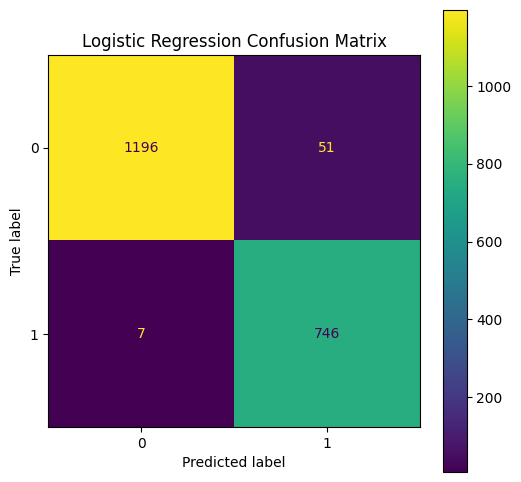

Saved confusion matrix to: ../outputs/confusion_matrix.png


In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create outputs directory
from pathlib import Path

outputs_dir = Path("../outputs")
outputs_dir.mkdir(exist_ok=True)

# Confusion matrix figure
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax
)

plt.title("Logistic Regression Confusion Matrix")

# Save figure
conf_matrix_path = outputs_dir / "confusion_matrix.png"
plt.savefig(conf_matrix_path, bbox_inches="tight")

plt.show()

print(f"Saved confusion matrix to: {conf_matrix_path}")

In [18]:
import joblib

# Save predictions
predictions_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

predictions_path = outputs_dir / "predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print(f"Saved predictions to: {predictions_path}")

# Save trained model
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "logistic_regression_pipeline.pkl"

joblib.dump(logistic_pipeline, model_path)

print(f"Saved model to: {model_path}")

Saved predictions to: ../outputs/predictions.csv
Saved model to: ../models/logistic_regression_pipeline.pkl


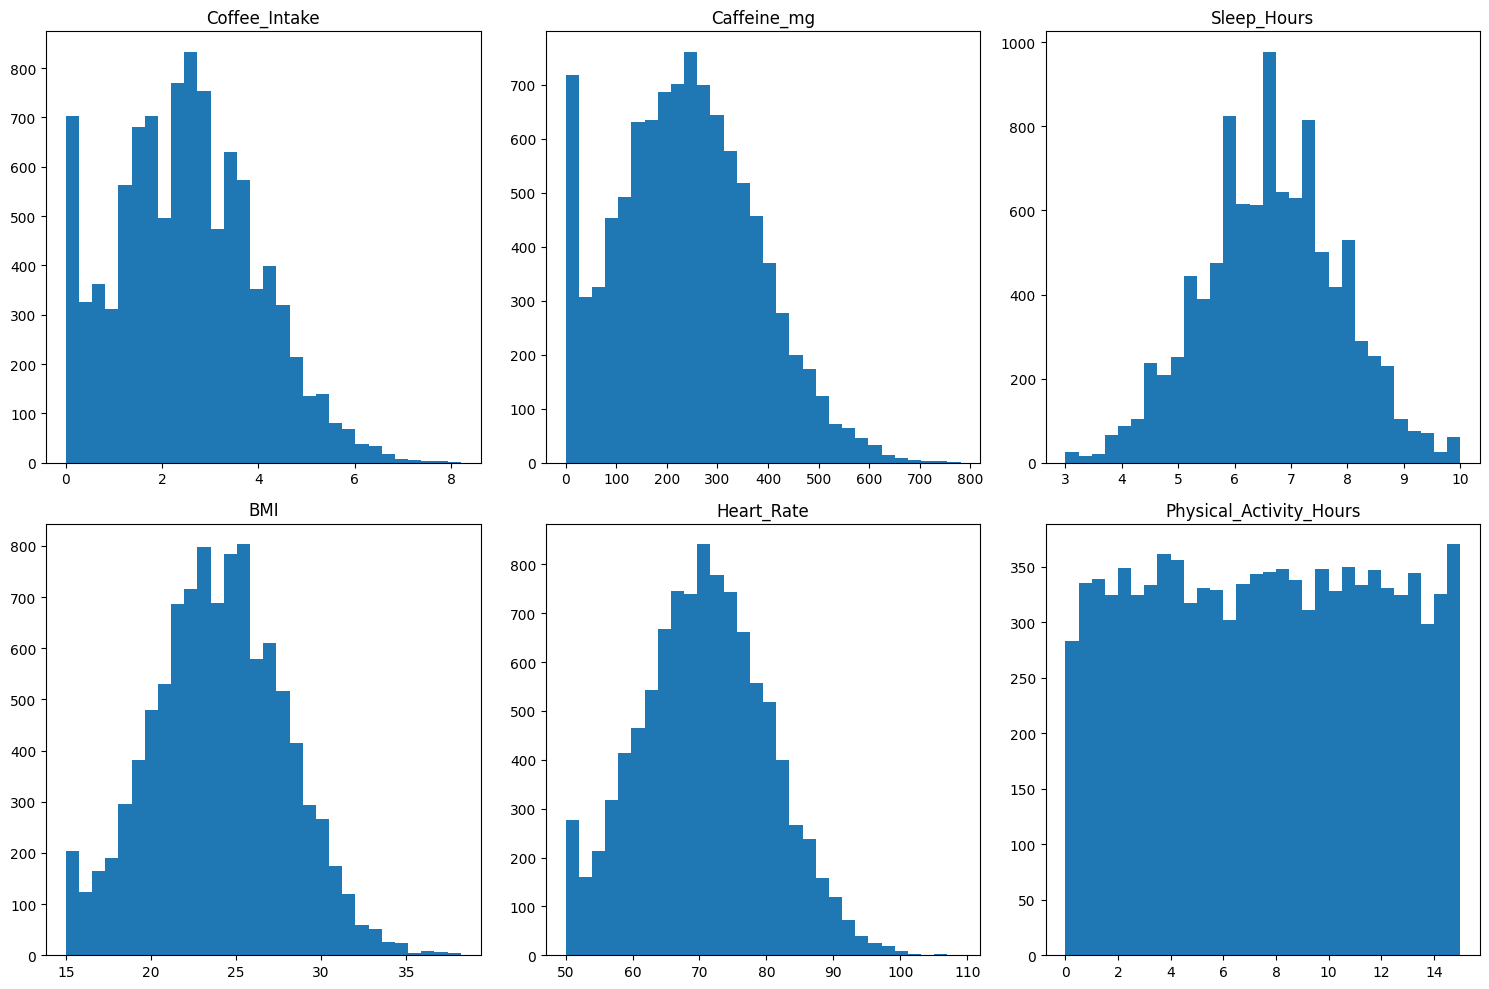

Saved feature distribution figure to: ../outputs/feature_distribution.png


In [19]:
# Feature distribution plots

numeric_features = [
    "Coffee_Intake",
    "Caffeine_mg",
    "Sleep_Hours",
    "BMI",
    "Heart_Rate",
    "Physical_Activity_Hours"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, feature in zip(axes.flatten(), numeric_features):
    ax.hist(df[feature], bins=30)
    ax.set_title(feature)

plt.tight_layout()

feature_dist_path = outputs_dir / "feature_distribution.png"

plt.savefig(feature_dist_path, bbox_inches="tight")

plt.show()

print(f"Saved feature distribution figure to: {feature_dist_path}")

In [20]:
# Create evaluation metrics table

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision_Class_1",
        "Recall_Class_1",
        "F1_Class_1"
    ],
    "Value": [
        accuracy,
        0.94,
        0.99,
        0.96
    ]
})

display(metrics_df)

metrics_path = outputs_dir / "evaluation_metrics.csv"

metrics_df.to_csv(metrics_path, index=False)

print(f"Saved metrics table to: {metrics_path}")

,Metric,Value
0,Accuracy,0.971
1,Precision_Class_1,0.940
2,Recall_Class_1,0.990
3,F1_Class_1,0.960


Saved metrics table to: ../outputs/evaluation_metrics.csv


# Decision Tree Model

In [21]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree model
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

# Predictions
tree_y_pred = tree_model.predict(X_test)

# Evaluation
tree_accuracy = accuracy_score(y_test, tree_y_pred)

print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, tree_y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_y_pred))

Decision Tree Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1247
           1       1.00      1.00      1.00       753

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix:
[[1247    0]
 [   0  753]]


# Discussion of Feature Leakage

## Observation About Decision Tree Performance

The Decision Tree model achieved nearly perfect classification performance.

This is likely caused by feature leakage because the engineered target variable (`Productivity_Label`) was directly derived from:

- Sleep_Hours
- Sleep_Quality
- Stress_Level

Since these same variables were also included as input features, the model was able to reconstruct the target rule almost perfectly.

This demonstrates an important machine learning limitation:
high predictive performance does not necessarily imply meaningful generalization or causal understanding.

# Feature Distribution Visualizations

In [26]:
# Compare model performances

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy
    ]
})

display(comparison_df)

comparison_path = outputs_dir / "model_comparison.csv"

comparison_df.to_csv(comparison_path, index=False)

print(f"Saved model comparison table to: {comparison_path}")

,Model,Accuracy
0,Logistic Regression,0.971
1,Decision Tree,1.000


Saved model comparison table to: ../outputs/model_comparison.csv


# Model Comparison

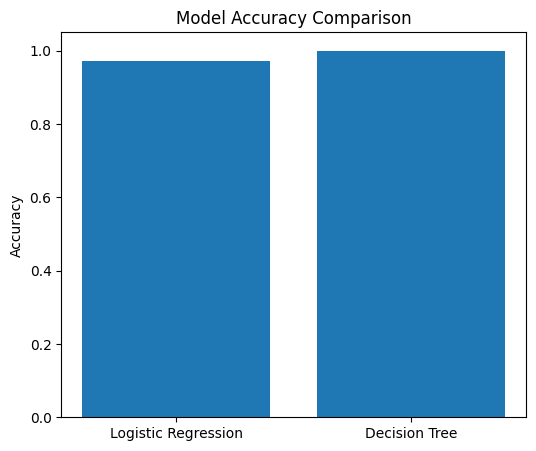

Saved model comparison figure to: ../outputs/model_comparison.png


In [24]:
# Model comparison figure

plt.figure(figsize=(6, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

comparison_fig_path = outputs_dir / "model_comparison.png"

plt.savefig(comparison_fig_path, bbox_inches="tight")

plt.show()

print(f"Saved model comparison figure to: {comparison_fig_path}")

# Conclusion

The experiment demonstrates how FAIR data science workflows, relational normalization, metadata standards, and reproducible machine learning practices can be integrated into a complete educational machine learning project.